In [1]:
import os

In [2]:
data_dir = 'cell_images'

In [3]:
os.listdir(data_dir)

['test', 'train']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
test_path = data_dir + '\\test\\'
train_path = data_dir + '\\train\\'

In [6]:
os.listdir(test_path)

['parasitized', 'uninfected']

In [7]:
os.listdir(train_path+'parasitized')[0]

'C100P61ThinF_IMG_20150918_144104_cell_162.png'

In [8]:
para_cell = train_path+'parasitized\\' + 'C100P61ThinF_IMG_20150918_144104_cell_162.png'
para_cell

'cell_images\\train\\parasitized\\C100P61ThinF_IMG_20150918_144104_cell_162.png'

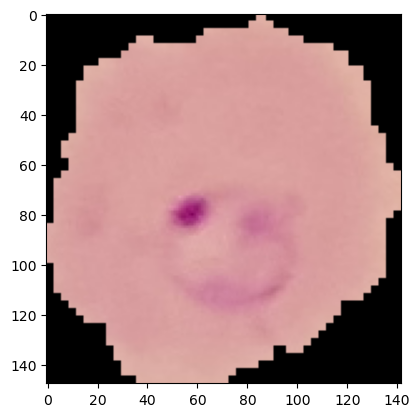

In [9]:
plt.imshow(imread(para_cell))

In [10]:
os.listdir(train_path + 'Uninfected')[0]

'C100P61ThinF_IMG_20150918_144104_cell_128.png'

In [11]:
uninfected_cell = train_path + 'Uninfected\\' + 'C100P61ThinF_IMG_20150918_144104_cell_128.png'
uninfected_cell

'cell_images\\train\\Uninfected\\C100P61ThinF_IMG_20150918_144104_cell_128.png'

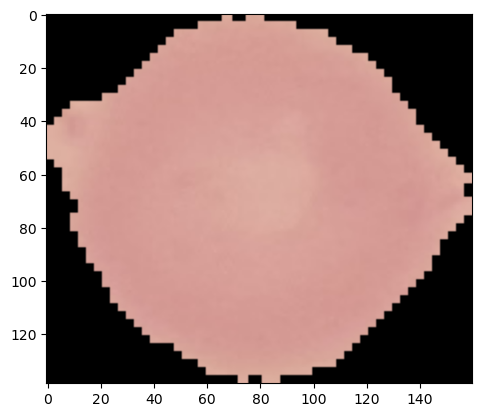

In [12]:
plt.imshow(imread(uninfected_cell))

In [13]:
print(len(os.listdir(train_path+'parasitized')))
print(len(os.listdir(test_path+'parasitized')))

print(len(os.listdir(train_path+'uninfected')))
print(len(os.listdir(test_path+'parasitized')))

12480
1300
12480
1300


In [14]:
dim1 = []
dim2 = []

for image_filename in os.listdir(test_path+'uninfected'):
    img = imread(test_path+'uninfected\\'+image_filename)
    d1, d2, colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

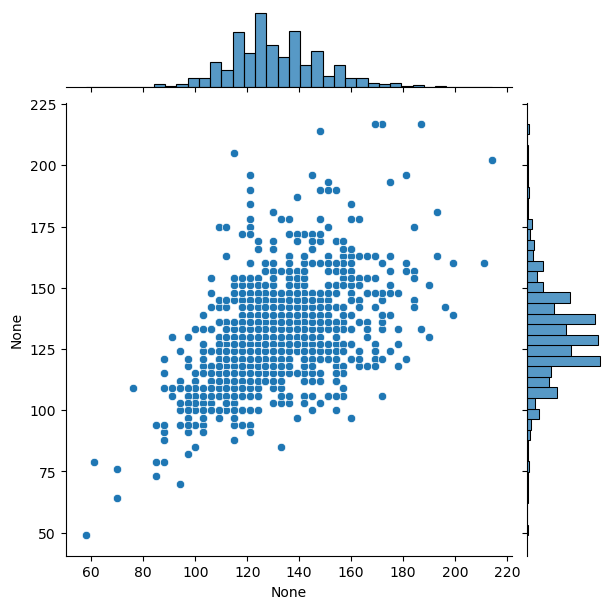

In [15]:
sns.jointplot(x=dim1, y=dim2)

In [16]:
image_shape = (130, 130, 3) 

In [17]:
img_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

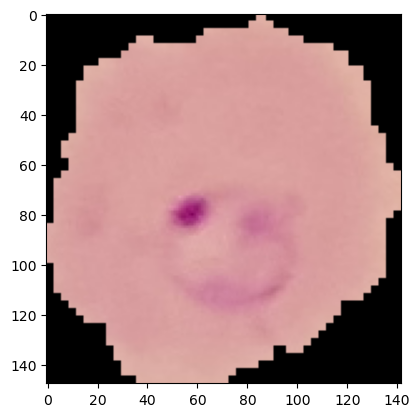

In [18]:
para_img = imread(para_cell)
plt.imshow(para_img)

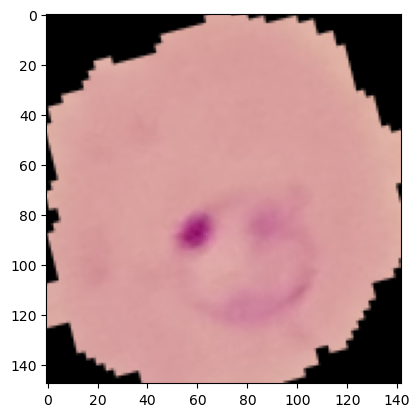

In [19]:
plt.imshow(img_gen.random_transform(para_img))

In [20]:
img_gen.flow_from_directory(train_path)

Found 24958 images belonging to 2 classes.


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Conv2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D

In [26]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(132, 132, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'),  # Added layer
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),  # Replaces Flatten to reduce parameters
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 132, 132, 32)      896       
                                                                 
 batch_normalization_7 (Batc  (None, 132, 132, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 66, 66, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 66, 66, 64)        18496     
                                                                 
 batch_normalization_8 (Batc  (None, 66, 66, 64)       256       
 hNormalization)                                                 
                                                      

In [27]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [29]:
batch_size = 16

In [30]:
train_image_gen = img_gen.flow_from_directory(train_path, 
                                                target_size=image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=batch_size,
                                                class_mode='binary'
                                               )

Found 24958 images belonging to 2 classes.


In [31]:
test_image_gen = img_gen.flow_from_directory(test_path, 
                                                target_size=image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=batch_size,
                                                class_mode='binary', 
                                             shuffle=False
                                               )

Found 2600 images belonging to 2 classes.


In [32]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [34]:
result = model.fit_generator(
    train_image_gen, epochs=20,
    validation_data=test_image_gen,
    callbacks=[early_stop]
)

Epoch 1/20


C:\Users\Ramsaheb Prasad\AppData\Local\Temp\ipykernel_8688\4242318059.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  result = model.fit_generator(


1560/1560 [==============================] - 100s 64ms/step - loss: 0.1193 - accuracy: 0.9604 - val_loss: 0.1214 - val_accuracy: 0.9627
Epoch 2/20
1560/1560 [==============================] - 103s 66ms/step - loss: 0.1176 - accuracy: 0.9618 - val_loss: 0.1195 - val_accuracy: 0.9600
Epoch 3/20
1560/1560 [==============================] - 100s 64ms/step - loss: 0.1150 - accuracy: 0.9625 - val_loss: 0.1119 - val_accuracy: 0.9588
Epoch 4/20
1560/1560 [==============================] - 114s 73ms/step - loss: 0.1156 - accuracy: 0.9616 - val_loss: 0.1457 - val_accuracy: 0.9546
Epoch 5/20
1560/1560 [==============================] - 202s 129ms/step - loss: 0.1135 - accuracy: 0.9623 - val_loss: 0.1225 - val_accuracy: 0.9577


In [35]:
model.history.history

{'loss': [0.11930712312459946,
  0.11761453747749329,
  0.11498241126537323,
  0.11564619094133377,
  0.11345071345567703],
 'accuracy': [0.9603734016418457,
  0.9617757797241211,
  0.9624969959259033,
  0.9616155028343201,
  0.9622966647148132],
 'val_loss': [0.12142464518547058,
  0.119452103972435,
  0.11189184337854385,
  0.14572688937187195,
  0.12253209203481674],
 'val_accuracy': [0.9626923203468323,
  0.9599999785423279,
  0.9588461518287659,
  0.9546154141426086,
  0.9576923251152039]}

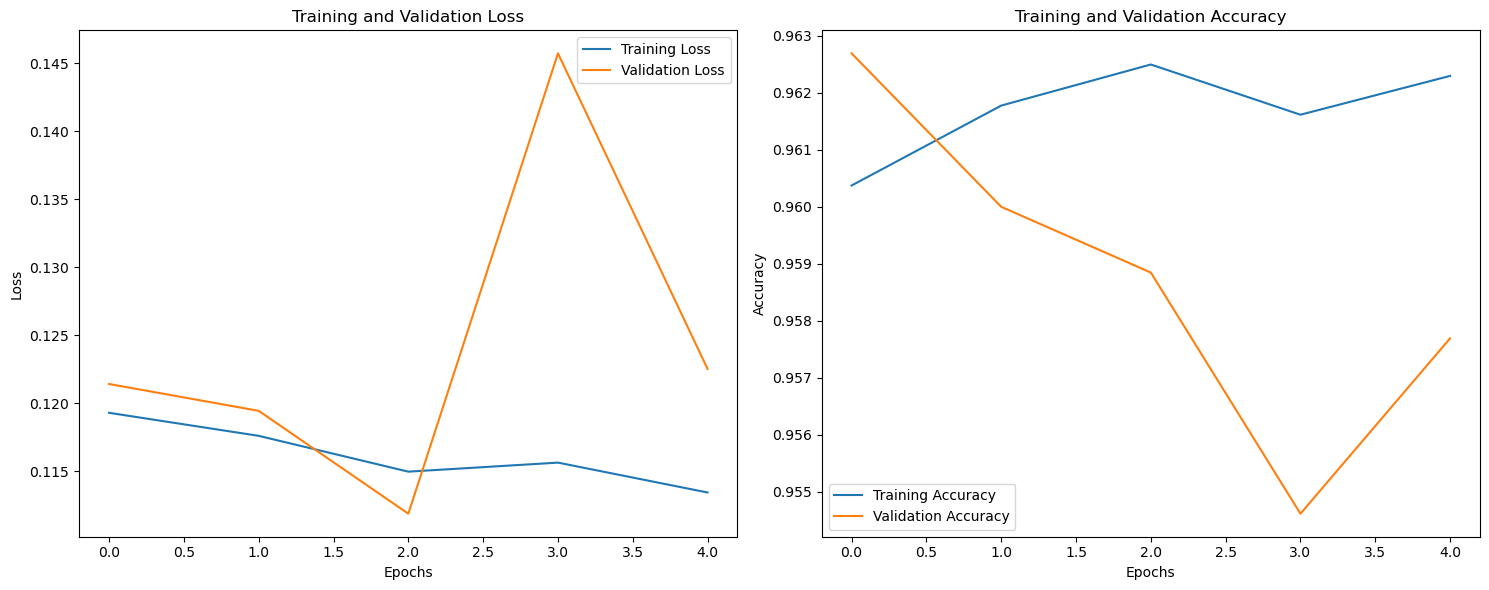

In [36]:
import matplotlib.pyplot as plt

# History data
history = {
    'loss': [0.11930712312459946, 0.11761453747749329, 0.11498241126537323, 0.11564619094133377, 0.11345071345567703],
    'accuracy': [0.9603734016418457, 0.9617757797241211, 0.9624969959259033, 0.9616155028343201, 0.9622966647148132],
    'val_loss': [0.12142464518547058, 0.119452103972435, 0.11189184337854385, 0.14572688937187195, 0.12253209203481674],
    'val_accuracy': [0.9626923203468323, 0.9599999785423279, 0.9588461518287659, 0.9546154141426086, 0.9576923251152039]
}

# Create a figure with 2 subplots (Loss and Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the Loss graph
ax1.plot(history['loss'], label='Training Loss')
ax1.plot(history['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot the Accuracy graph
ax2.plot(history['accuracy'], label='Training Accuracy')
ax2.plot(history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# Display the plots
plt.tight_layout()
plt.show()


In [40]:
from sklearn.metrics import classification_report, confusion_matrix
predictions = model.predict(test_image_gen)

163/163 [==============================] - 8s 52ms/step


In [42]:
predicted_labels = np.argmax(predictions, axis=1)

# Now you can pass the predicted labels to classification_report
from sklearn.metrics import classification_report
print(classification_report(test_image_gen.classes, predicted_labels))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1300
           1       0.00      0.00      0.00      1300

    accuracy                           0.50      2600
   macro avg       0.25      0.50      0.33      2600
weighted avg       0.25      0.50      0.33      2600



C:\Anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
